# **ERC en población afrodescendiente: Datos del manuscrito**

##### **Librerías**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML
import math
from scipy.stats import spearmanr, pearsonr
from scipy.stats import chi2_contingency
from scipy.stats import shapiro
from scipy.stats import ks_2samp
import unicodedata

##### **Funciones**

In [2]:
def resumen_var_cat(df):
    conteo = df.value_counts(dropna=False)
    porcentaje = df.value_counts(normalize=True, dropna=False) * 100
    
    resumen = pd.DataFrame({
        'Categorías': conteo.index,
        'Conteo': conteo.values,
        'Porcentaje': porcentaje.values.round(2)
    })
    
    resumen = resumen.head(10) 
    
    styled = resumen.style \
        .format({'porcentaje': '{:.2f}%'})
    
    display(styled)

In [3]:
def prueba_kolmogrov(df_original,df_imputed,variable1, variable2):
    stat, p = ks_2samp(df_original[variable1].dropna(), df_imputed[variable2].dropna())
    print(f"KS statistic: {stat:.3f}, p-value: {p:.3f}")

    if(p > 0.05):
        print("No hay evidencia estadísticamente significativa que evidencia que las distribuciones difieran")
    else:
        print("La distribución cambió significativamente")

In [4]:
def distribucion_cruzada (df_original, df_imputed, variable):
    sns.kdeplot(df_original[variable].dropna(), label='Original')
    sns.kdeplot(df_imputed[variable], label='Imputado')
    plt.legend()
    plt.show()

In [5]:
def analizar_misma_variable(df1, df2, columna, color1="#4682B4", color2="#FF6347"):
    f, ((ax_box1, ax_hist1), (ax_box2, ax_hist2)) = plt.subplots(2, 2, sharex='col', figsize=(12, 10))
    
    sns.boxplot(x=df1[columna], ax=ax_box1, color=color1, fliersize=5)
    ax_box1.set(xlabel='') 
    ax_box1.set_title(f'Distribución de la Variable: {columna} en df1', fontsize=14)
    
    sns.histplot(df1[columna], ax=ax_hist1, kde=True, color=color1, bins=30)
    ax_hist1.set_xlabel(f'Valores de {columna}', fontsize=12)
    ax_hist1.set_ylabel('Frecuencia', fontsize=12)
    
    sns.boxplot(x=df2[columna], ax=ax_box2, color=color2, fliersize=5)
    ax_box2.set(xlabel='') 
    ax_box2.set_title(f'Distribución de la Variable: {columna} en df2', fontsize=14)
    
    sns.histplot(df2[columna], ax=ax_hist2, kde=True, color=color2, bins=30)
    ax_hist2.set_xlabel(f'Valores de {columna}', fontsize=12)
    ax_hist2.set_ylabel('Frecuencia', fontsize=12)
    
    plt.tight_layout()  
    plt.show()

In [6]:
def prueba_normalidad_shap (df, variable):
    stat, p = shapiro(df[variable].dropna())
    print('Estadístico=%.3f, p=%.3f' % (stat, p))

    if p > 0.05:
        print('No se rechaza H0 → parece normal')
    else:
        print('Se rechaza H0 → no es normal')

In [7]:
def cramers_v(tabla):
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape
    return np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

def matriz_asociacion_categoricas(df, variables, figsize=(12,10), annot=True):
    matriz_v = pd.DataFrame(index=variables, columns=variables, dtype=float)
    matriz_p = pd.DataFrame(index=variables, columns=variables, dtype=float)

    resultados = []

    for i, var1 in enumerate(variables):
        for j, var2 in enumerate(variables):
            if var1 == var2:
                matriz_v.loc[var1, var2] = 1.0
                matriz_p.loc[var1, var2] = np.nan
            else:
                tabla = pd.crosstab(df[var1], df[var2])

                if tabla.shape[0] < 2 or tabla.shape[1] < 2:
                    matriz_v.loc[var1, var2] = np.nan
                    matriz_p.loc[var1, var2] = np.nan
                else:
                    chi2, p, dof, expected = chi2_contingency(tabla)
                    v = cramers_v(tabla)

                    matriz_v.loc[var1, var2] = v
                    matriz_p.loc[var1, var2] = p

                    if i < j:  
                        resultados.append([var1, var2, v, p])

    plt.figure(figsize=figsize)
    sns.heatmap(
        matriz_v.astype(float),
        annot=annot,
        cmap="Blues",
        fmt=".2f",
        linewidths=0.5,
        square=True,
        cbar_kws={"shrink": 0.8}
    )
    plt.title("Matriz de Asociación entre Variables Categóricas (V de Cramér)", fontsize=14)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    tabla_asociaciones = pd.DataFrame(resultados, columns=["Variable_1", "Variable_2", "V_Cramer", "p_valor"])
    tabla_asociaciones = tabla_asociaciones.sort_values(by="V_Cramer", ascending=False).reset_index(drop=True)

    return matriz_v, matriz_p, tabla_asociaciones

In [8]:
import pandas as pd
from scipy.stats import chi2_contingency

def prueba_chi_cuadrado(df, var1, var2):
    tabla_contingencia = pd.crosstab(df[var1], df[var2])
    
    chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
    
    tabla_porcentajes = pd.crosstab(df[var1], df[var2], normalize='columns') * 100
    
    tabla_formateada = tabla_contingencia.copy().astype(str)
    for col in tabla_contingencia.columns:
        tabla_formateada[col] = (
            tabla_contingencia[col].astype(str) + 
            " (" + tabla_porcentajes[col].map("{:.1f}".format) + "%)"
        )
    
    print(f"=== PRUEBA CHI-CUADRADO: {var1} vs {var2} ===")
    print(f"Estadístico Chi2: {chi2:.4f}")
    print(f"p-valor: {p:.4e}")
    print(f"Grados de libertad: {dof}")
    print("-" * 40)
    
    if p < 0.05:
        print("Existe una RELACIÓN significativa entre las variables (p < 0.05).")
    else:
        print("NO hay evidencia de relación. Las variables son independientes.")
    
    print("\n--- Tabla de Frecuencias Observadas (Porcentaje por Columna) ---")
    display(tabla_formateada)
    
    return p

In [9]:
def grafico_dispersion(df, x, y, metodo_corr="spearman", figsize=(8,6)):
    data = df[[x, y]].dropna()
    if metodo_corr.lower() == "spearman":
        corr, p_value = spearmanr(data[x], data[y])
    elif metodo_corr.lower() == "pearson":
        corr, p_value = pearsonr(data[x], data[y])
    else:
        raise ValueError("metodo_corr debe ser 'spearman' o 'pearson'")

    plt.figure(figsize=figsize)

    sns.regplot(
        data=data,
        x=x,
        y=y,
        scatter_kws={"alpha": 0.7},
        line_kws={"linewidth": 2},
        color="#5B8DB8"
    )

    plt.title(f"Gráfico de Dispersión: {x} vs {y}", fontsize=14)
    plt.xlabel(x, fontsize=12)
    plt.ylabel(y, fontsize=12)
    plt.grid(alpha=0.2)
    plt.text(
        0.05, 0.95,
        f"{metodo_corr.capitalize()} = {corr:.2f}\np = {p_value:.4f}",
        transform=plt.gca().transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.3", edgecolor="gray", facecolor="white")
    )

    plt.tight_layout()
    plt.show()

    return corr, p_value

In [10]:
import pandas as pd

def tabla_frecuencias_comparada(df1, col1, df2, col2, nombre_df1='Categorías originales', nombre_df2='Categorías agrupadas'):

    def obtener_estadisticos(df, columna, etiqueta):
        abs_freq = df[columna].value_counts(dropna=False)
        
        rel_freq = (df[columna].value_counts(normalize=True, dropna=False) * 100).round(2)
        
        temp_df = pd.DataFrame({
            'Categoría': abs_freq.index,
            'Frec. Absoluta': abs_freq.values,
            'Frec. Relativa (%)': rel_freq.values
        })
        
        temp_df['Variable / Origen'] = f"{etiqueta} ({columna})"
        return temp_df

    stats1 = obtener_estadisticos(df1, col1, nombre_df1)
    stats2 = obtener_estadisticos(df2, col2, nombre_df2)

    resultado = pd.concat([stats1, stats2], axis=0)
    
    resultado = resultado.set_index(['Variable / Origen', 'Categoría'])
    
    return resultado

In [11]:
def resumen_categorica(df, columna, incluir_na=False, ordenar_por_frecuencia=True, figsize=(8,5)):
    
    freq_abs = df[columna].value_counts(dropna=not incluir_na)
    
    freq_rel = df[columna].value_counts(normalize=True, dropna=not incluir_na) * 100
    
    tabla_freq = pd.DataFrame({
        columna: freq_abs.index,
        "Frecuencia Absoluta": freq_abs.values,
        "Frecuencia Relativa (%)": freq_rel.values.round(2)
    })
    
    if ordenar_por_frecuencia:
        tabla_freq = tabla_freq.sort_values(by="Frecuencia Absoluta", ascending=False).reset_index(drop=True)
    
    colores = sns.color_palette("Blues", n_colors=len(tabla_freq) + 2)[2:]
    
    plt.figure(figsize=figsize)
    ax = sns.barplot(
        data=tabla_freq,
        x=columna,
        y="Frecuencia Absoluta",
        palette=colores
    )
    
    plt.title(f"Distribución de la Variable: {columna}", fontsize=14)
    plt.xlabel(columna, fontsize=12)
    plt.ylabel("Frecuencia Absoluta", fontsize=12)
    plt.xticks(rotation=45)
    
    for i, row in tabla_freq.iterrows():
        ax.text(
            i,
            row["Frecuencia Absoluta"] + 0.5,
            f'{row["Frecuencia Relativa (%)"]:.1f}%',
            ha='center',
            va='bottom',
            fontsize=10
        )
    
    plt.tight_layout()
    plt.show()
    
    return tabla_freq

In [12]:
def analizar_distribucion(df, columna, color="#4682B4"):
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                        gridspec_kw={"height_ratios": (.15, .85)},
                                        figsize=(8, 6))
    
    sns.boxplot(x=df[columna], ax=ax_box, color=color, fliersize=5)
    ax_box.set(xlabel='') 
    ax_box.set_title(f'Distribución de la Variable: {columna}', fontsize=14)
    
    sns.histplot(df[columna], ax=ax_hist, kde=True, color=color, bins=30)
    ax_hist.set_xlabel(f'Valores de {columna}', fontsize=12)
    ax_hist.set_ylabel('Frecuencia', fontsize=12)
    
    plt.tight_layout()
    plt.show()

In [13]:
def Resumen_Faltantes(df):
    faltantes = df.isnull().sum()
    porcentaje = (faltantes / len(df)) * 100

    tabla_faltantes = pd.DataFrame({
        'Valores faltantes': faltantes,
        'Porcentaje (%)': porcentaje
    })

    tabla_faltantes = tabla_faltantes[tabla_faltantes['Valores faltantes'] > 0]
    tabla_faltantes.sort_values('Porcentaje (%)', ascending=False)
    return tabla_faltantes

In [14]:
def comparar_categoricas(df, col1, col2, incluir_na=False, ordenar_por_frecuencia=True, figsize=(12, 6)):
    
    def tabla_frecuencia(df, columna):
        counts = df[columna].value_counts(dropna=not incluir_na)
        total = len(df[columna]) if incluir_na else df[columna].count()
        
        tabla = pd.DataFrame({
            columna: counts.index,
            "Frecuencia Absoluta": counts.values,
            "Frecuencia Relativa (%)": (counts.values / total * 100).round(2)
        })
        
        if ordenar_por_frecuencia:
            tabla = tabla.sort_values(by="Frecuencia Absoluta", ascending=False).reset_index(drop=True)
        return tabla

    tabla1 = tabla_frecuencia(df, col1)
    tabla2 = tabla_frecuencia(df, col2)
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    sns.barplot(data=tabla1, x=col1, y="Frecuencia Absoluta", color="#5B8DB8", ax=axes[0])
    axes[0].set_title(f"Distribución de {col1}")
    axes[0].tick_params(axis='x', rotation=45)
    for i, row in tabla1.iterrows():
        axes[0].text(i, row["Frecuencia Absoluta"] + 0.5, f'{row["Frecuencia Relativa (%)"]}%', 
                     ha='center', va='bottom', fontsize=9)
    
    sns.barplot(data=tabla2, x=col2, y="Frecuencia Absoluta", color="#89A8C9", ax=axes[1])
    axes[1].set_title(f"Distribución de {col2}")
    axes[1].tick_params(axis='x', rotation=45)
    for i, row in tabla2.iterrows():
        axes[1].text(i, row["Frecuencia Absoluta"] + 0.5, f'{row["Frecuencia Relativa (%)"]}%', 
                     ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

    html_t1 = tabla1.to_html(index=False)
    html_t2 = tabla2.to_html(index=False)
    
    display(HTML(f"""
    <div style="display: flex; justify-content: flex-start; gap: 40px; padding-left: 5%; width: 100%;">
        <div style="min-width: 300px; max-width: 45%;">{html_t1}</div>
        <div style="min-width: 300px; max-width: 45%;">{html_t2}</div>
    </div>
    <style>
        .dataframe {{
            border-collapse: collapse;
            border: none;
            width: 100%;
        }}
        .dataframe th {{
            background-color: #f2f2f2;
            text-align: left;
            padding: 8px;
        }}
        .dataframe td {{
            padding: 8px;
            border-bottom: 1px solid #ddd;
        }}
    </style>
    """))

In [15]:
def matriz_barras_categoricas(df, columnas, incluir_na=False, ncols=3, figsize_por_grafico=(6, 4)):
    tablas_frecuencia = {}

    n = len(columnas)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_por_grafico[0] * ncols, figsize_por_grafico[1] * nrows)
    )

    axes = axes.flatten() if n > 1 else [axes]

    for i, col in enumerate(columnas):
        ax = axes[i]

        freq_abs = df[col].value_counts(dropna=not incluir_na)
        freq_rel = df[col].value_counts(normalize=True, dropna=not incluir_na) * 100

        tabla = pd.DataFrame({
            col: freq_abs.index.astype(str),
            "Frecuencia Absoluta": freq_abs.values,
            "Frecuencia Relativa (%)": freq_rel.values.round(2)
        })

        tablas_frecuencia[col] = tabla

        colores = sns.color_palette("Blues", n_colors=len(tabla) + 2)[2:]

        sns.barplot(
            data=tabla,
            x=col,
            y="Frecuencia Absoluta",
            palette=colores,
            ax=ax
        )

        ax.set_title(col, fontsize=12)
        ax.set_xlabel("")
        ax.set_ylabel("Frecuencia")
        ax.tick_params(axis='x', rotation=45)

        for j, row in tabla.iterrows():
            ax.text(
                j,
                row["Frecuencia Absoluta"] + max(tabla["Frecuencia Absoluta"]) * 0.01,
                f'{row["Frecuencia Relativa (%)"]:.1f}%',
                ha='center',
                va='bottom',
                fontsize=9
            )

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

    return tablas_frecuencia

In [16]:
def imputacion_por_mediana(df, columna):
    mediana = df[columna].median()

    df[columna].fillna(mediana, inplace=True)

    return df

In [17]:
def analizar_comparativa(df1, df2, col1, col2, color1="#4682B4", color2="#FF6347"):
    f, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    sns.boxplot(x=df1[col1], ax=axes[0, 0], color=color1, fliersize=5)
    axes[0, 0].set_title(f'Boxplot: {col1} (DF1)', fontsize=12)
    
    sns.histplot(df1[col1], ax=axes[0, 1], kde=True, color=color1, bins=30)
    axes[0, 1].set_title(f'Histograma: {col1} (DF1)', fontsize=12)
    
    sns.boxplot(x=df2[col2], ax=axes[1, 0], color=color2, fliersize=5)
    axes[1, 0].set_title(f'Boxplot: {col2} (DF2)', fontsize=12)
    
    sns.histplot(df2[col2], ax=axes[1, 1], kde=True, color=color2, bins=30)
    axes[1, 1].set_title(f'Histograma: {col2} (DF2)', fontsize=12)
    
    plt.tight_layout()
    plt.show()

## **Data Sources**

In [18]:
df = pd.read_excel("df_afro_clean.xlsx")

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1357 entries, 0 to 1356
Data columns (total 62 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GRUPO                         1357 non-null   object 
 1   Departamento_Tamizaje         1357 non-null   object 
 2   Municipio_Tamizaje            1357 non-null   object 
 3   Edad                          1357 non-null   int64  
 4   Genero                        1357 non-null   object 
 5   Escolaridad                   1357 non-null   object 
 6   Regimen_Salud                 1357 non-null   object 
 7   Ocupacion                     1357 non-null   object 
 8   Medicacion_Diabetes           1357 non-null   object 
 9   Diabetes_Embarazo             1357 non-null   object 
 10  Hipertension                  1357 non-null   object 
 11  Medicacion_Hipertension       1357 non-null   object 
 12  Colesterol_Alto               1357 non-null   object 
 13  Med

La base de datos consta de **1357 registros** y 62 variables.

La doctora inicia el artículo con una base de datos que incluye a **1590 individuos**. Esta cantidad coincide con los registros de la base de datos del cuestionario_1, una base de datos dada anteriormente por la clínica, pero la base de datos fue actualizada debido a que contaba con 258 registros duplicados. Además, no sería correcto afirmar que se cuentan con esa cantidad de individuos sin haber verificado anteriormente los registros duplicados, por lo que los datos mencionados podrían ser erróneos.

In [20]:
df["Presion_Sistolica	> 130"] = df["Presion_Sistolica	> 130"].astype("object")
df["Presion_Diastolica > 90"] = df["Presion_Diastolica > 90"].astype("object")

### **Verificación de registros duplicados:**

In [21]:
print("En este dataset podemos encontrar {} resgistros duplicados".format(df.duplicated().sum()))

En este dataset podemos encontrar 1 resgistros duplicados


In [22]:
df[df.duplicated(keep = False)]

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,...,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
407,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,41,Femenino,Técnica,No tiene,Desempleado,No,No,...,NaN,NaN,110.0,60.0,No,0,0,>1.70,>80,Alto
1023,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,41,Femenino,Técnica,No tiene,Desempleado,No,No,...,NaN,NaN,110.0,60.0,No,0,0,>1.70,>80,Alto


Ante la presencia de un registro duplicado, se conserva el que aparece en primer lugar y se elimina aquel que se encuentra en una posición posterior, bajo el supuesto de que el primer registro corresponde a la captura original y los siguientes podrían derivarse de errores de digitación, reprocesamiento o redundancias en la recolección de la información.

In [23]:
df= df.drop_duplicates(keep='first')
print("Dentro del dataset aun quedan {} registros duplicados".format(df.duplicated().sum()))

Dentro del dataset aun quedan 0 registros duplicados


In [24]:
df[df.duplicated(keep=False)]

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,...,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC


Finalmente, la base de datos contaría con 1356 individuos.

### **Verificación de lugares de tamizajes**

**Departamentos**

In [25]:
df['Departamento_Tamizaje'].unique()

array(['BOLIVAR', 'ATLANTICO', 'PALENQUE'], dtype=object)

In [26]:
df["Departamento_Tamizaje"] = df["Departamento_Tamizaje"].replace({
    "PALENQUE":"BOLIVAR"
})

In [27]:
df['Departamento_Tamizaje'].unique()

array(['BOLIVAR', 'ATLANTICO'], dtype=object)

**Municipios**

In [28]:
df['Municipio_Tamizaje'].unique()

array(['MARIA LA BAJA', 'BARRANQUILLA', 'PALENQUE', 'LOMITA ARENA',
       'PONTEZUELA', 'SAN JOSE DE SACO'], dtype=object)

En el artículo, la doctora menciona:

Rural communities included San Basilio de Palenque (Bolívar), San José de Saco and **Lomita Arena (Atlántico)**, and María la Baja (Bolívar). 
Urban sampling included Afro-descendant neighborhoods in **Cartagena (Bolívar)**, Barranquilla (Atlántico), **Maicao (La Guajira)**, and **Magdalena**. In Cartagena, areas such as **Cerro de la Popa** have long been inhabited by Afro-descendant populations who, despite conditions of socioeconomic marginalization, have preserved cultural traditions. Similarly, in Barranquilla, neighborhoods such as **Nueva Colombia** and **El Valle** in the southwestern part of the city represent important sites of cultural resilience and identity.

Las ciudades/municipios resaltados no se encuentran en la base de datos.

In [29]:
# Esto crea una serie donde el índice es el Departamento
relacion = df.groupby('Departamento_Tamizaje')['Municipio_Tamizaje'].unique()

# Para verlo de forma estética en una tabla
for depto, municipios in relacion.items():
    print(f"** {depto} **")
    print(f"{', '.join(municipios)}\n")

** ATLANTICO **
BARRANQUILLA, SAN JOSE DE SACO

** BOLIVAR **
MARIA LA BAJA, PALENQUE, LOMITA ARENA, PONTEZUELA



**Individuos mayores a 18 años**

In [30]:
print(f"El valor de la muestra hasta ahora {len(df)}")
print(f"El número de personas menores de 18 años es {len(df[df['Edad']<18])}")
df = df[df['Edad']>=18]
print(f"la muestra excluyendo a los menores de 18 años quedo con {len(df)} registros")

El valor de la muestra hasta ahora 1356
El número de personas menores de 18 años es 13
la muestra excluyendo a los menores de 18 años quedo con 1343 registros


Después de filtrar los datos según el criterio de exclusión: individuos de 18 años o mayores, resultan **1343 individuos**.

**Observación con información pérdida en la varible 'Regimen_Salud'**

In [31]:
df['Regimen_Salud'].unique()

array(['Subsidiado', 'No tiene', 'Contributivo', 'Especial', 'N.d.'],
      dtype=object)

Se supone que la observación excluida es la que tiene la categoría "N.d.".

In [32]:
df[df["Regimen_Salud"]=="N.d."]

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,...,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
1233,AFRODESCENDIENTE,BOLIVAR,PALENQUE,58,Femenino,No escolarizado,N.d.,Desempleado,No,No,...,NaN,NaN,120.0,87.0,No,0,0,1.61-1.70,41-60,Normal


**Observaciones con valores anómalos en la variable 'Peso'**

In [33]:
df[df['Peso']<35]

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,...,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
50,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,70,Femenino,Primaria,Subsidiado,Desempleado,No,No,...,NaN,NaN,149.0,79.0,No,1,0,1.61-1.70,<40,Bajo
51,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,61,Femenino,No escolarizado,Subsidiado,Agricultor,Si,No,...,NaN,NaN,159.0,90.0,No,1,0,1.61-1.70,<40,Bajo
91,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,50,Femenino,Técnica,Subsidiado,Desempleado,No,No,...,117.09,80.0,117.0,82.0,No,0,0,1.50-1.60,<40,Bajo
769,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,70,Femenino,Primaria,Subsidiado,Desempleado,No,No,...,NaN,NaN,149.0,79.0,No,1,0,1.61-1.70,<40,Bajo
795,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,50,Femenino,Técnica,Subsidiado,Desempleado,No,No,...,NaN,NaN,117.0,82.0,No,0,0,1.50-1.60,<40,Bajo


Efectivamente, si existen 5 registros que corresponden a esta anomalías.

**Observaciones con valores anómalos de IMC**

In [34]:
df[df['IMC']<15]

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,...,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
50,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,70,Femenino,Primaria,Subsidiado,Desempleado,No,No,...,NaN,NaN,149.0,79.0,No,1,0,1.61-1.70,<40,Bajo
51,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,61,Femenino,No escolarizado,Subsidiado,Agricultor,Si,No,...,NaN,NaN,159.0,90.0,No,1,0,1.61-1.70,<40,Bajo
55,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,72,Femenino,Primaria,Subsidiado,Desempleado,No,No,...,NaN,NaN,172.0,84.0,No,1,0,>1.70,<40,Bajo
69,AFRODESCENDIENTE,BOLIVAR,PALENQUE,56,Femenino,Universitaria,Contributivo,Otro,No,No,...,NaN,NaN,119.0,93.0,No,0,1,>1.70,41-60,Bajo
83,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,35,Femenino,Posgrado,No tiene,Comerciante,No,No,...,NaN,NaN,117.0,80.0,No,0,0,>1.70,41-60,Bajo
91,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,50,Femenino,Técnica,Subsidiado,Desempleado,No,No,...,117.09,80.0,117.0,82.0,No,0,0,1.50-1.60,<40,Bajo
214,AFRODESCENDIENTE,BOLIVAR,LOMITA ARENA,47,Femenino,Secundaria,Subsidiado,Desempleado,No,No aplica,...,NaN,NaN,120.0,70.0,No,0,0,>1.70,41-60,Bajo
378,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,61,Femenino,Bachiller,Especial,Desempleado,No,No,...,NaN,NaN,120.0,80.0,No,0,0,>1.70,41-60,Bajo
434,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,24,Femenino,Universitaria,Subsidiado,Otro,No,No,...,NaN,NaN,114.0,75.0,No,0,0,1.61-1.70,<40,Bajo
531,AFRODESCENDIENTE,ATLANTICO,SAN JOSE DE SACO,88,Femenino,No escolarizado,Subsidiado,Desempleado,No,No,...,NaN,NaN,130.0,70.0,No,0,0,1.61-1.70,<40,Bajo


In [35]:
IMC_BAJO = df[df['IMC']<15]
len(IMC_BAJO)

15

Note que existen 15 registros con esta anomalía, sin haber eliminado las anomalías anteriores.

In [36]:
df.loc[(df["Peso"]<35)&(df["IMC"]<15),["Peso","IMC","Talla"]]

,Peso,IMC,Talla
50,31,11.959415,1.61
51,24,9.144947,1.62
91,31,12.576575,1.57
769,31,11.959415,1.61
795,31,12.576575,1.57


Note que los 5 registros que cumplen con el peso $< 35kg$ tambien cumplen con la anomalia de tener un IMC $<15kg/m^2$

In [37]:
df.loc[(df["Peso"]>=35)&(df["IMC"]<15),["Peso","IMC","Talla"]]

,Peso,IMC,Talla
55,35,10.923504,1.79
69,42,12.962963,1.80
83,46,14.682882,1.77
214,45,14.202752,1.78
378,45,14.363689,1.77
434,40,14.172336,1.68
531,40,14.342572,1.67
782,42,12.962963,1.80
788,46,14.682882,1.77
1040,40,14.172336,1.68


Esto nos deja con 10 individuos que cumplen exclusivamente con el criterio de un IMC < 15 $kg/m^2$, debido a que presentan un peso significativamente bajo en relación con su estatura.

In [38]:
df = df[df['Regimen_Salud']!='N.d.']
df=df[((df['Peso']>=35)&(df["IMC"]>=15))&(df["IMC"]>15)]
len(df)

1327

En total, se procedio a eliminar 16 registros unicos consolidando una muestra de **1327 individuos**.

### **Diagrama de Flujo Limpieza de Datos**

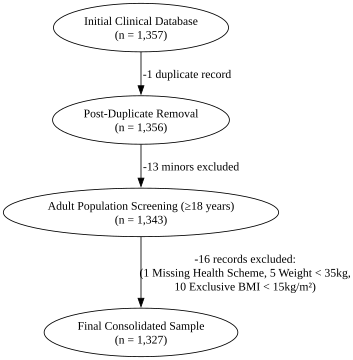

In [39]:
import graphviz

dot = graphviz.Digraph(comment='Data Cleaning Workflow')
dot.attr(rankdir='TB', size='8,5')

# Nodes - Using "Records" and "Observations" for technical precision
dot.node('A', 'Initial Clinical Database\n(n = 1,357)')
dot.node('B', 'Post-Duplicate Removal\n(n = 1,356)')
dot.node('C', 'Adult Population Screening (≥18 years)\n(n = 1,343)')
dot.node('D', 'Final Consolidated Sample\n(n = 1,327)')

# Edges - Using clear exclusion labels
dot.edge('A', 'B', label=' -1 duplicate record')
dot.edge('B', 'C', label=' -13 minors excluded')
dot.edge('C', 'D', label='-16 records excluded:\n(1 Missing Health Scheme, 5 Weight < 35kg,\n10 Exclusive BMI < 15kg/m²)')

dot.render('data_cleaning_flow', format='png', cleanup=True)
dot

### **Manipulación de la base de datos según recomendaciones:**

**Valores faltantes**

c:\Users\Mari\miniconda3\envs\deepl_venv\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Mari\miniconda3\envs\deepl_venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


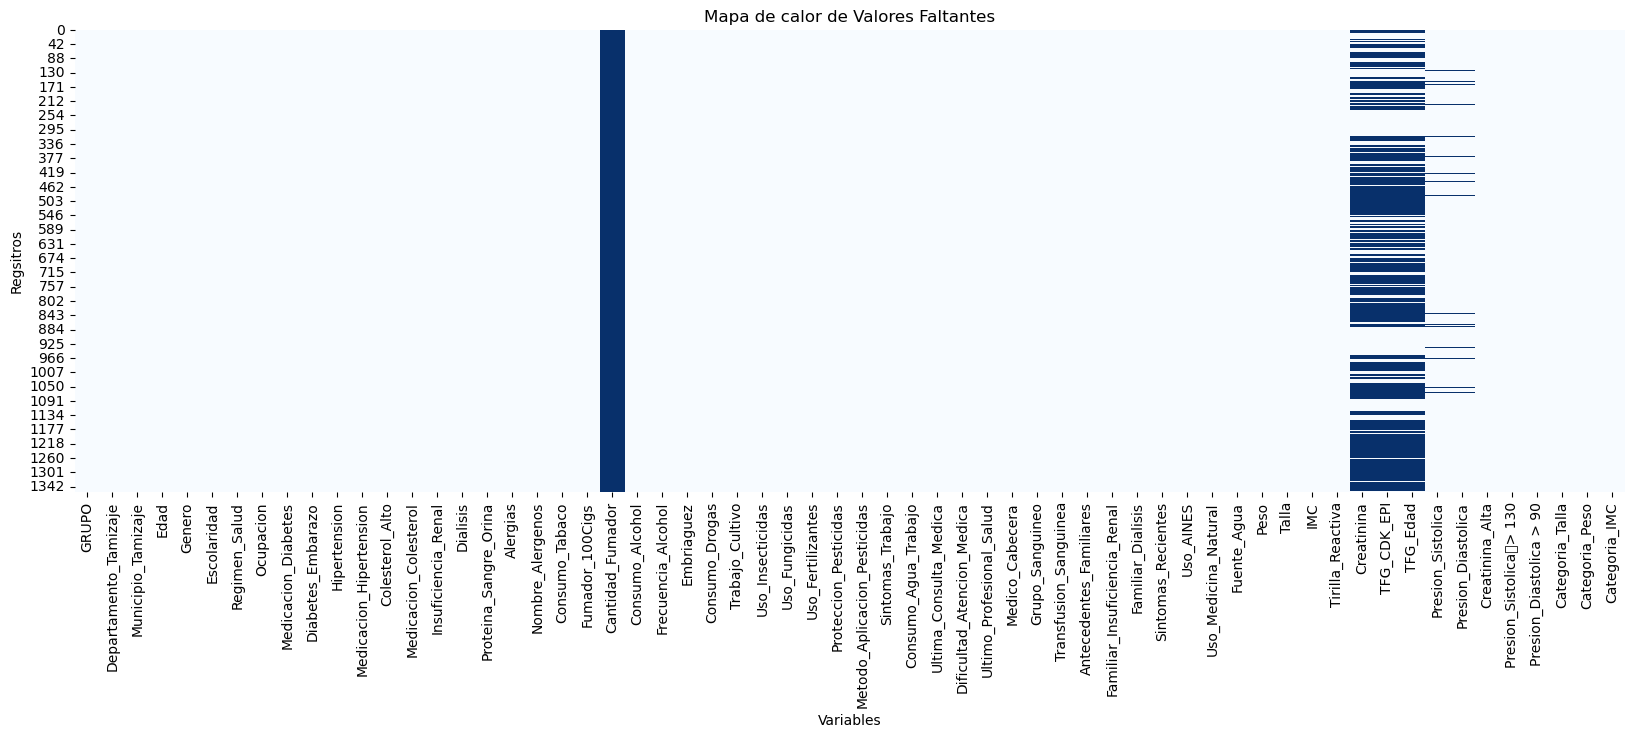

In [40]:
plt.figure(figsize = (20,6))
sns.heatmap(df.isnull(),cbar=False,cmap= "Blues")
plt.title("Mapa de calor de Valores Faltantes")
plt.xlabel("Variables")
plt.ylabel("Regsitros")
plt.show()

In [41]:
Resumen_Faltantes(df)

,Valores faltantes,Porcentaje (%)
Cantidad_Fumador,1327,100.000000
Creatinina,861,64.883195
TFG_CDK_EPI,861,64.883195
TFG_Edad,861,64.883195
Presion_Sistolica,47,3.541824
Presion_Diastolica,47,3.541824


La variable ``Cantidad_Fumador``, al encontrarse completamente vacía, será eliminada de la base de datos.

In [42]:
df = df.drop(columns = "Cantidad_Fumador")

 Por otro lado, las variables ``Presion_Sistolica`` y ``Presion_Diastolica`` presentan un 3.46% de valores faltantes (aproximadamente 47 registros), por lo que se imputa por la mediana, según las sugerencias dadas.

**Eliminación de variables**

In [43]:
var_eliminar = ['Alergias', 'Ocupacion', 'Embriaguez', 'Sintomas_Trabajo', 'Nombre_Alergenos']

df = df.drop(columns=var_eliminar)

**Reagrupación de categorías:**

In [44]:
df_agrupado = df.copy()

**`Escolaridad:`**

In [45]:
df_agrupado["Escolaridad"] = df_agrupado["Escolaridad"].replace({
    "Secundaria":"Secundaria-Bachiller",
    "Bachiller":"Secundaria-Bachiller",
    "Técnica":"Educación_Superior",
    "Tecnológa":"Educación_Superior",
    "Universitaria":"Educación_Superior",
    "Posgrado":"Educación_Superior",
    "Primaria":"No_escolarizado-Primaria",
    "No  escolarizado":"No_escolarizado-Primaria"
})

In [46]:
resumen_var_cat(df_agrupado["Escolaridad"])

,Categorías,Conteo,Porcentaje
0,Secundaria-Bachiller,467,35.190000
1,No_escolarizado-Primaria,458,34.510000
2,Educación_Superior,402,30.290000


**`Regimen_Salud:`**

In [47]:
df_agrupado["Regimen_Salud"] = df_agrupado["Regimen_Salud"].replace({
    "Contributivo": "Contributivo-Especial", 
    "Subsidiado": "Subsidiado-No_Tiene", 
    "Especial": "Contributivo-Especial", 
    "No tiene": "Subsidiado-No_Tiene"})

In [48]:
resumen_var_cat(df_agrupado["Regimen_Salud"])

,Categorías,Conteo,Porcentaje
0,Subsidiado-No_Tiene,971,73.170000
1,Contributivo-Especial,356,26.830000


**`Consumo_Agua_Trabajo:`**

In [49]:
df_agrupado["Consumo_Agua_Trabajo"] = df_agrupado["Consumo_Agua_Trabajo"].replace({
    "Mas de 1 litro": "Consumo adecuado", 
    "Mas de 200 cc": "No toma nada", 
    "Mas de 5 litros": "No toma nada", 
    "Menos de 100 cc": "Consumo elevado"
    })

In [50]:
resumen_var_cat(df_agrupado["Consumo_Agua_Trabajo"])

,Categorías,Conteo,Porcentaje
0,Consumo adecuado,763,57.500000
1,No toma nada,508,38.280000
2,Consumo elevado,56,4.220000


**`Frecuencia_Alcohol:`**

In [51]:
df_agrupado["Frecuencia_Alcohol"] = df_agrupado["Frecuencia_Alcohol"].replace({
    "Menos de 1 vez al mes":"Consumo_Ocasional",
    "1-2 veces por mes":"Consumo_Ocasional",
    "1-2 veces por semana":"Consumo_Frecuente",
    "3-4 veces por semana":"Consumo_Frecuente",
    "Diario":"Consumo_Habitual"})

In [52]:
resumen_var_cat(df_agrupado["Frecuencia_Alcohol"])

,Categorías,Conteo,Porcentaje
0,Nunca,876,66.010000
1,Consumo_Ocasional,349,26.300000
2,Consumo_Frecuente,96,7.230000
3,Consumo_Habitual,5,0.380000
4,Casi diario,1,0.080000


**`Ultima_Consulta_Medica:`**

In [53]:
df_agrupado["Ultima_Consulta_Medica"] = df_agrupado["Ultima_Consulta_Medica"].replace({
    "Hace una semana": "Atención reciente",
    "Hace un mes": "Atención reciente",
    "Mayor a un mes": "Atención intermedia",
    "Mayor a 3 meses": "Atención intermedia",
    "Mayor a 6 meses": "Atención intermedia",
    "Mayor a 1 año": "Atención tardía",
    "Mayor a 2 años": "Atención tardía"
})

In [54]:
resumen_var_cat(df_agrupado["Ultima_Consulta_Medica"])

,Categorías,Conteo,Porcentaje
0,Atención tardía,546,41.150000
1,Atención intermedia,429,32.330000
2,Atención reciente,352,26.530000


**`Dificultad_Atencion_Medica`:**

In [55]:
df_agrupado["Dificultad_Atencion_Medica"] = df_agrupado["Dificultad_Atencion_Medica"].replace({
    "Muy Facil": "Sin dificultad",
    "Facil": "Sin dificultad",
    "Difícil": "Con dificultad",
    "Muy Dificil": "Con dificultad"
})

In [56]:
resumen_var_cat(df_agrupado["Dificultad_Atencion_Medica"])

,Categorías,Conteo,Porcentaje
0,Sin dificultad,811,61.120000
1,Con dificultad,516,38.880000


**`Ultimo_Profesional_Salud:`**

In [57]:
df_agrupado["Ultimo_Profesional_Salud"] = df_agrupado["Ultimo_Profesional_Salud"].replace({
    "Medico General": "Medicina General",
    "Internista": "Especialista",
    "Nefrólogo": "Especialista",
    "Cardiologo": "Especialista",
    'Enfermera':'Medicina General',
    'Endocrinologo':'Especialista'
})

In [58]:
resumen_var_cat(df_agrupado["Ultimo_Profesional_Salud"])

,Categorías,Conteo,Porcentaje
0,Medicina General,1120,84.400000
1,Especialista,207,15.600000


**`Grupo_Sanguineo:`**

In [59]:
df_agrupado["Grupo_Sanguineo"] = df_agrupado["Grupo_Sanguineo"].replace({
    "A+": "No O",
    "A-": "No O",
    "AB+": "No O",
    "B+": "No O",
    "B-":"No O"
})

In [60]:
resumen_var_cat(df_agrupado["Grupo_Sanguineo"])

,Categorías,Conteo,Porcentaje
0,O+,847,63.830000
1,No O,459,34.590000
2,O-,21,1.580000


**`IMC`:**

In [61]:
df_agrupado["Categoria_IMC"] = df_agrupado["Categoria_IMC"].replace({
    "Obesidad 1": "Obesidad",
    "Obesidad 2": "Obesidad",
    "Obesidad 3": "Obesidad"
})

In [62]:
resumen_var_cat(df_agrupado["Categoria_IMC"])

,Categorías,Conteo,Porcentaje
0,Normal,450,33.910000
1,Alto,431,32.480000
2,Obesidad,351,26.450000
3,Bajo,95,7.160000


In [63]:
df = df_agrupado

**Recalculación de variables numéricas**

**`IMC:`**

In [64]:
def calcular_imc(df, col_peso, col_estatura):
    df['IMC_CAL'] = df[col_peso] / (df[col_estatura] ** 2)
    
    df['IMC_CAL'] = df['IMC_CAL'].round(2)

In [65]:
calcular_imc(df, 'Peso', 'Talla')

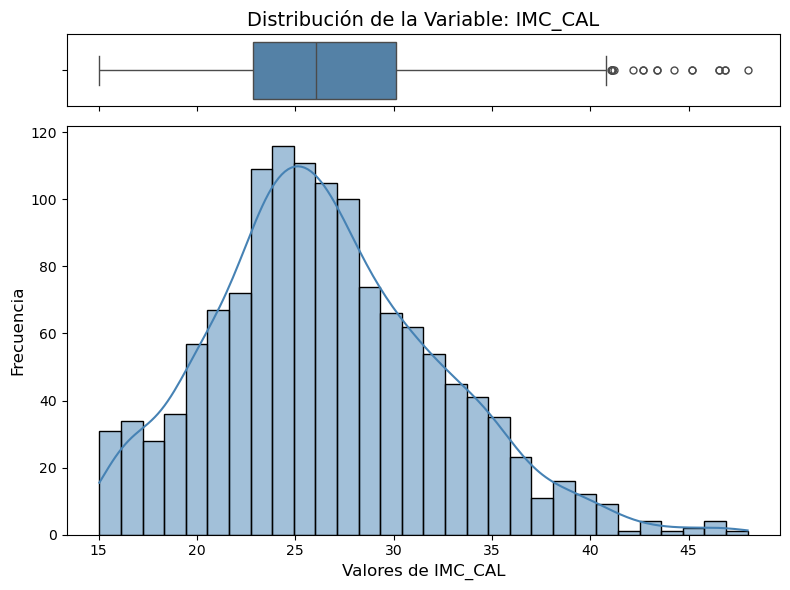

In [66]:
analizar_distribucion(df,"IMC_CAL")

**`TFG calculada:`**

Se calcula la TFG según la fórmula internacional recomendada por la KDIGO.

$$TFGe = 142 \times \min(Cr/\kappa, 1)^\alpha \times \max(Cr/\kappa, 1)^{-1.200} \times 0.9938^{Edad} \times [1.012 \text{ si es mujer}]$$

Donde:
* $Cr$: Creatinina sérica en mg/dL.
* $\kappa$: 0.7 para mujeres, 0.9 para hombres.
* $\alpha$: -0.241 para mujeres, -0.302 para hombres.

In [67]:
import numpy as np

def calcular_tfg_ckdepi(creatinina, edad, sexo):

    sexo = sexo.lower()
    
    es_mujer = (sexo == 'femenino')
    kappa = 0.7 if es_mujer else 0.9
    alpha = -0.302 if not es_mujer else -0.241
    factor_genero = 1.012 if es_mujer else 1.0
    
    t1 = np.power(min(creatinina / kappa, 1), alpha)
    t2 = np.power(max(creatinina / kappa, 1), -1.200)
    
    tfg = 142 * t1 * t2 * (0.9938 ** edad) * factor_genero
    return tfg

In [68]:
df["TFG_CDK_EPI_CAL"] = df.apply(
    lambda row: calcular_tfg_ckdepi(row['Creatinina'], row['Edad'], row['Genero']), 
    axis=1
)

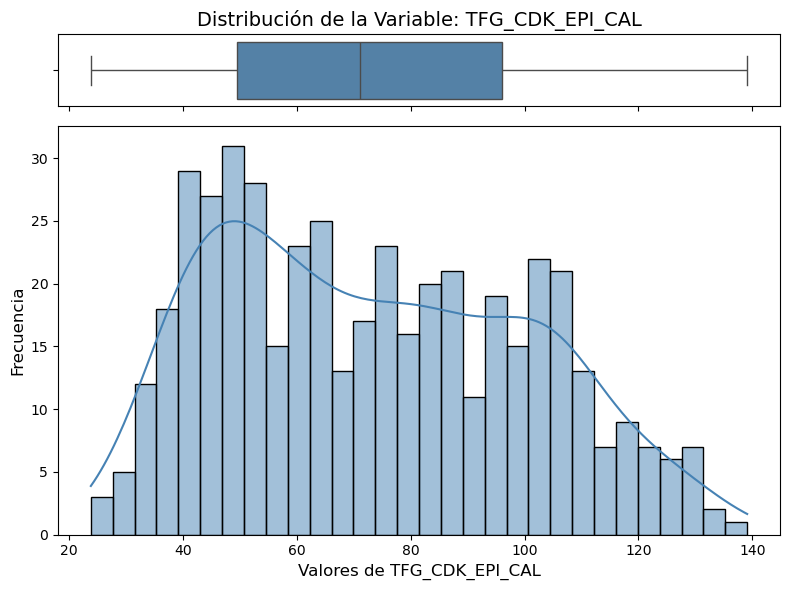

In [69]:
analizar_distribucion(df,"TFG_CDK_EPI_CAL")

In [70]:
bins_erc = [0, 15, 30, 60, 90, np.inf]

labels_erc = [
    "G5: Falla Renal (<15)",
    "G4: Descenso Grave (15-29)",
    "G3: Descenso Moderado (30-59)",
    "G2: Descenso Leve (60-89)",
    "G1: Normal o Elevado (≥90)"
]

df["Estadio_ERC_CAL"] = pd.cut(
    df["TFG_CDK_EPI_CAL"], 
    bins=bins_erc, 
    labels=labels_erc, 
    right=False
)

In [71]:
resumen_var_cat(df['Estadio_ERC_CAL'])

,Categorías,Conteo,Porcentaje
0,nan,861,64.880000
1,G3: Descenso Moderado (30-59),177,13.340000
2,G2: Descenso Leve (60-89),149,11.230000
3,G1: Normal o Elevado (≥90),136,10.250000
4,G4: Descenso Grave (15-29),4,0.300000
5,G5: Falla Renal (<15),0,0.000000


**Creación de la variable dicotómica de estadio de ERC**

In [72]:
df['Estadio_ERC_Binaria'] = df['Estadio_ERC_CAL']

df['Estadio_ERC_Binaria'] = df['Estadio_ERC_Binaria'].replace({
    "G5: Falla Renal (<15)" : 'Moderado',
    "G4: Descenso Grave (15-29)" : 'Moderado',
    "G3: Descenso Moderado (30-59)" : 'Moderado',
    "G2: Descenso Leve (60-89)" : 'No moderado',
    'G1: Normal o Elevado (≥90)':'No moderado'
})

C:\Users\Mari\AppData\Local\Temp\ipykernel_13876\196292477.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Estadio_ERC_Binaria'] = df['Estadio_ERC_Binaria'].replace({


In [73]:
resumen_var_cat(df['Estadio_ERC_Binaria'])

,Categorías,Conteo,Porcentaje
0,nan,861,64.880000
1,No moderado,285,21.480000
2,Moderado,181,13.640000


## **Results**

In [74]:
len(df)

1327

El estudio incluiría **1327 individuos**.

In [75]:
df['Edad'].describe()

count    1327.000000
mean       46.045215
std        17.724753
min        18.000000
25%        31.000000
50%        46.000000
75%        58.000000
max        97.000000
Name: Edad, dtype: float64

Con una **edad media de 46.05 años**, cuya **desviación estándar es de 17.72 años**.

In [76]:
resumen_var_cat(df['Genero'])

,Categorías,Conteo,Porcentaje
0,Femenino,850,64.050000
1,Masculino,477,35.950000


De estso individuos, el **64.05%** se identifican con el **género femenino**.

In [77]:
resumen_var_cat(df['Tirilla_Reactiva'])

,Categorías,Conteo,Porcentaje
0,Negativo,1001,75.430000
1,Positiva,326,24.570000


El **24.57%** de los participantes resultaron **positivos para proteinuria**.

### **Datos de asociación con respecto a la variable `Tirilla_Reactiiva`**

In [78]:
df_prot = df[df['Tirilla_Reactiva']=='Positiva']
df_sin_prot = df[df['Tirilla_Reactiva']=='Negativo']

In [79]:
df_prot['Edad'].describe()

count    326.000000
mean      47.309816
std       17.177240
min       18.000000
25%       36.000000
50%       46.000000
75%       58.000000
max       94.000000
Name: Edad, dtype: float64

In [80]:
df_sin_prot['Edad'].describe()

count    1001.000000
mean       45.633367
std        17.888556
min        18.000000
25%        30.000000
50%        46.000000
75%        58.000000
max        97.000000
Name: Edad, dtype: float64

In [81]:
from scipy import stats

def comparar_grupos(data, columna_valor, columna_grupo):
    grupos = data[columna_grupo].unique()

    g1 = data[data[columna_grupo] == grupos[0]][columna_valor].dropna()
    g2 = data[data[columna_grupo] == grupos[1]][columna_valor].dropna()
    
    # 1. Prueba de Normalidad (Shapiro-Wilk)
    # p > 0.05 significa que los datos parecen normales
    norm_g1 = stats.shapiro(g1).pvalue > 0.05
    norm_g2 = stats.shapiro(g2).pvalue > 0.05
    
    print(f"--- Análisis para {columna_valor} ---")
    
    if norm_g1 and norm_g2:
        # 2. Prueba de Homocedasticidad (Levene)
        # p > 0.05 significa varianzas iguales
        igual_var = stats.levene(g1, g2).pvalue > 0.05
        
        # T-Test de Student o Welch
        t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=igual_var)
        prueba = "T-test (Paramétrica)" if igual_var else "Welch T-test (Paramétrica)"
    else:
        # 3. Prueba No Paramétrica (Mann-Whitney U)
        u_stat, p_val = stats.mannwhitneyu(g1, g2)
        prueba = "Mann-Whitney U (No Paramétrica)"
    
    print(f"Prueba utilizada: {prueba}")
    print(f"P-valor: {p_val:.4f}")
    
    if p_val < 0.05:
        print("Resultado: Hay una diferencia estadísticamente significativa (p < 0.05).")
    else:
        print("Resultado: No se encontraron diferencias significativas.")
        
    return p_val

In [82]:
comparar_grupos(df, 'Edad', 'Tirilla_Reactiva')

--- Análisis para Edad ---
Prueba utilizada: Mann-Whitney U (No Paramétrica)
P-valor: 0.1308
Resultado: No se encontraron diferencias significativas.


0.13079701085664502

Concuerda con los resultados.

In [83]:
import pandas as pd
from scipy.stats import chi2_contingency

def comparar_categoricas(data, var1, var2):
    # 1. Crear la tabla de contingencia (frecuencias observadas)
    tabla = pd.crosstab(data[var1], data[var2])
    
    # 2. Realizar la prueba Chi-cuadrado
    chi2, p_val, dof, expected = chi2_contingency(tabla)
    
    print(f"Comparación: {var1} vs {var2}")
    print(f"P-valor: {p_val:.4f}")
    
    if p_val < 0.05:
        print("Resultado: Existe una asociación significativa entre las variables (p < 0.05).")
    else:
        print("Resultado: No se encontró asociación significativa (independientes).")
    
    print("\nTabla de porcentajes por columna (%):")
    tabla_pct = pd.crosstab(data[var1], data[var2], normalize='columns') * 100
    print(tabla_pct.round(2))
    
    return p_val

In [84]:
comparar_categoricas(df, 'Tirilla_Reactiva', 'Genero')

Comparación: Tirilla_Reactiva vs Genero
P-valor: 0.0418
Resultado: Existe una asociación significativa entre las variables (p < 0.05).

Tabla de porcentajes por columna (%):
Genero            Femenino  Masculino
Tirilla_Reactiva                     
Negativo             77.29      72.12
Positiva             22.71      27.88


0.041795358670738476

No concuerda con el artículo, debido a que se dice que: "A lower proportion of women had proteinuria compared to men (59.2% vs. 65.8%, p = 0.030)".

In [85]:
comparar_categoricas(df, 'Tirilla_Reactiva', 'Escolaridad')

Comparación: Tirilla_Reactiva vs Escolaridad
P-valor: 0.0100
Resultado: Existe una asociación significativa entre las variables (p < 0.05).

Tabla de porcentajes por columna (%):
Escolaridad       Educación_Superior  No_escolarizado-Primaria  \
Tirilla_Reactiva                                                 
Negativo                       72.39                     80.35   
Positiva                       27.61                     19.65   

Escolaridad       Secundaria-Bachiller  
Tirilla_Reactiva                        
Negativo                         73.23  
Positiva                         26.77  


0.010030783362745226

Si concuerda, hay diferencias significativas.

In [86]:
comparar_categoricas(df, 'Tirilla_Reactiva', 'Regimen_Salud')

Comparación: Tirilla_Reactiva vs Regimen_Salud
P-valor: 0.5607
Resultado: No se encontró asociación significativa (independientes).

Tabla de porcentajes por columna (%):
Regimen_Salud     Contributivo-Especial  Subsidiado-No_Tiene
Tirilla_Reactiva                                            
Negativo                          74.16                 75.9
Positiva                          25.84                 24.1


0.5606738410577955

In [87]:
comparar_categoricas(df, 'Tirilla_Reactiva', 'Medico_Cabecera')

Comparación: Tirilla_Reactiva vs Medico_Cabecera
P-valor: 0.0000
Resultado: Existe una asociación significativa entre las variables (p < 0.05).

Tabla de porcentajes por columna (%):
Medico_Cabecera      No    Si
Tirilla_Reactiva             
Negativo          80.24  54.1
Positiva          19.76  45.9


2.1178570626626056e-17

In [88]:
comparar_categoricas(df, 'Tirilla_Reactiva', 'Dificultad_Atencion_Medica')

Comparación: Tirilla_Reactiva vs Dificultad_Atencion_Medica
P-valor: 0.0000
Resultado: Existe una asociación significativa entre las variables (p < 0.05).

Tabla de porcentajes por columna (%):
Dificultad_Atencion_Medica  Con dificultad  Sin dificultad
Tirilla_Reactiva                                          
Negativo                             82.56            70.9
Positiva                             17.44            29.1


2.097894496412622e-06

In [89]:
comparar_categoricas(df, 'Tirilla_Reactiva', 'Medicacion_Hipertension')

Comparación: Tirilla_Reactiva vs Medicacion_Hipertension
P-valor: 0.0000
Resultado: Existe una asociación significativa entre las variables (p < 0.05).

Tabla de porcentajes por columna (%):
Medicacion_Hipertension    No     Si
Tirilla_Reactiva                    
Negativo                 81.8  57.59
Positiva                 18.2  42.41


3.6910692940788e-19

In [90]:
comparar_categoricas(df, 'Tirilla_Reactiva', 'Medicacion_Diabetes')

Comparación: Tirilla_Reactiva vs Medicacion_Diabetes
P-valor: 0.8735
Resultado: No se encontró asociación significativa (independientes).

Tabla de porcentajes por columna (%):
Medicacion_Diabetes     No     Si
Tirilla_Reactiva                 
Negativo             75.52  74.03
Positiva             24.48  25.97


0.8735148813756927

In [91]:
comparar_categoricas(df, 'Tirilla_Reactiva', 'Consumo_Tabaco')

Comparación: Tirilla_Reactiva vs Consumo_Tabaco
P-valor: 0.6580
Resultado: No se encontró asociación significativa (independientes).

Tabla de porcentajes por columna (%):
Consumo_Tabaco       No    Si
Tirilla_Reactiva             
Negativo          75.21  77.3
Positiva          24.79  22.7


0.6580291239178286

In [92]:
comparar_categoricas(df, 'Tirilla_Reactiva', 'Antecedentes_Familiares')

Comparación: Tirilla_Reactiva vs Antecedentes_Familiares
P-valor: 0.0000
Resultado: Existe una asociación significativa entre las variables (p < 0.05).

Tabla de porcentajes por columna (%):
Antecedentes_Familiares   ACV   Artritis reumatoide   Cancer  Colesterol   \
Tirilla_Reactiva                                                            
Negativo                 100.0                 100.0   74.55        100.0   
Positiva                   0.0                   0.0   25.45          0.0   

Antecedentes_Familiares  Diabetes Mellitus  Enfermedad Cardiaca  \
Tirilla_Reactiva                                                  
Negativo                             91.08                100.0   
Positiva                              8.92                  0.0   

Antecedentes_Familiares  Enfermedad Renal  Gastritis cronica  \
Tirilla_Reactiva                                               
Negativo                            73.91              100.0   
Positiva                            26.

1.3821011095807562e-27

In [93]:
df['Antecedentes_Familiares'].unique()

array(['Hipertensión Arterial', 'Diabetes Mellitus',
       'Enfermedad Cardiaca', 'No', 'Cancer', 'Gastritis cronica',
       'Enfermedad Renal', 'ACV ', 'Artritis reumatoide ',
       'Neurofibromatosis', 'Hipotiroidismo', 'Parkinson', 'Colesterol ',
       'Hernia lumbosacras '], dtype=object)

In [94]:
df['Antecedentes_Familiares'] = df['Antecedentes_Familiares'].replace({
    "ACV " : 'No_ERC',
    'Artritis reumatoide ' : 'No_ERC',
    "Hipertensión Arterial" : 'No_ERC',
    "Diabetes Mellitus" : 'No_ERC',
    'Enfermedad Cardiaca':'No_ERC',
    'Cancer':'No_ERC',
    'Gastritis cronica':'No_ERC',
    'Neurofibromatosis':'No_ERC',
    'Hipotiroidismo':'No_ERC',
    'Parkinson':'No_ERC',
    'Colesterol ':'No_ERC',
    'Hernia lumbosacras ':'No_ERC', 
    'No':'No_ERC'
})

In [95]:
comparar_categoricas(df, 'Tirilla_Reactiva', 'Antecedentes_Familiares')

Comparación: Tirilla_Reactiva vs Antecedentes_Familiares
P-valor: 1.0000
Resultado: No se encontró asociación significativa (independientes).

Tabla de porcentajes por columna (%):
Antecedentes_Familiares  Enfermedad Renal  No_ERC
Tirilla_Reactiva                                 
Negativo                            73.91   75.46
Positiva                            26.09   24.54


1.0

In [96]:
comparar_categoricas(df, 'Tirilla_Reactiva', 'Frecuencia_Alcohol')

Comparación: Tirilla_Reactiva vs Frecuencia_Alcohol
P-valor: 0.0009
Resultado: Existe una asociación significativa entre las variables (p < 0.05).

Tabla de porcentajes por columna (%):
Frecuencia_Alcohol  Casi diario  Consumo_Frecuente  Consumo_Habitual  \
Tirilla_Reactiva                                                       
Negativo                  100.0              89.58              60.0   
Positiva                    0.0              10.42              40.0   

Frecuencia_Alcohol  Consumo_Ocasional  Nunca  
Tirilla_Reactiva                              
Negativo                        79.37  72.37  
Positiva                        20.63  27.63  


0.0009075458700876134

In [97]:
df['Frecuencia_Alcohol'].unique()

array(['Nunca', 'Consumo_Ocasional', 'Consumo_Frecuente', 'Casi diario',
       'Consumo_Habitual'], dtype=object)

In [98]:
df['Frecuencia_Alcohol'] = df['Frecuencia_Alcohol'].replace({
    "Consumo_Ocasional" : 'Consume',
    'Consumo_Frecuente' : 'Consume',
    "Casi diario" : 'Consume',
    "Consumo_Habitual" : 'Consume',
    'Nunca':'No_consume'
})

In [99]:
comparar_categoricas(df, 'Tirilla_Reactiva', 'Frecuencia_Alcohol')

Comparación: Tirilla_Reactiva vs Frecuencia_Alcohol
P-valor: 0.0004
Resultado: Existe una asociación significativa entre las variables (p < 0.05).

Tabla de porcentajes por columna (%):
Frecuencia_Alcohol  Consume  No_consume
Tirilla_Reactiva                       
Negativo              81.37       72.37
Positiva              18.63       27.63


0.000399842677305393

In [100]:
comparar_categoricas(df, 'Tirilla_Reactiva', 'Uso_Fungicidas')

Comparación: Tirilla_Reactiva vs Uso_Fungicidas
P-valor: 0.0380
Resultado: Existe una asociación significativa entre las variables (p < 0.05).

Tabla de porcentajes por columna (%):
Uso_Fungicidas       No     Si
Tirilla_Reactiva              
Negativo          76.01  63.33
Positiva          23.99  36.67


0.03801123141804963

In [101]:
comparar_grupos(df, 'IMC', 'Tirilla_Reactiva')

--- Análisis para IMC ---
Prueba utilizada: Mann-Whitney U (No Paramétrica)
P-valor: 0.0040
Resultado: Hay una diferencia estadísticamente significativa (p < 0.05).


0.004004380182610489

In [102]:
comparar_categoricas(df, 'Tirilla_Reactiva', 'Departamento_Tamizaje')

Comparación: Tirilla_Reactiva vs Departamento_Tamizaje
P-valor: 0.0000
Resultado: Existe una asociación significativa entre las variables (p < 0.05).

Tabla de porcentajes por columna (%):
Departamento_Tamizaje  ATLANTICO  BOLIVAR
Tirilla_Reactiva                         
Negativo                   72.09    83.42
Positiva                   27.91    16.58


1.6676562165228936e-05

In [103]:
comparar_categoricas(df, 'Tirilla_Reactiva', 'Municipio_Tamizaje')

Comparación: Tirilla_Reactiva vs Municipio_Tamizaje
P-valor: 0.0000
Resultado: Existe una asociación significativa entre las variables (p < 0.05).

Tabla de porcentajes por columna (%):
Municipio_Tamizaje  BARRANQUILLA  LOMITA ARENA  MARIA LA BAJA  PALENQUE  \
Tirilla_Reactiva                                                          
Negativo                   70.97         55.67          85.71     96.81   
Positiva                   29.03         44.33          14.29      3.19   

Municipio_Tamizaje  PONTEZUELA  SAN JOSE DE SACO  
Tirilla_Reactiva                                  
Negativo                 84.72             73.74  
Positiva                 15.28             26.26  


1.5447057391459589e-15

In [104]:
df['Municipio_Tamizaje'].unique()

array(['MARIA LA BAJA', 'BARRANQUILLA', 'PALENQUE', 'LOMITA ARENA',
       'PONTEZUELA', 'SAN JOSE DE SACO'], dtype=object)

In [105]:
df['Municipio_Tamizaje'] = df['Municipio_Tamizaje'].replace({
    "BARRANQUILLA" : 'Zona_urbana',
    'LOMITA ARENA' : 'Zona_rural',
    "SAN JOSE DE SACO" : 'Zona_rural',
    "MARIA LA BAJA" : 'Zona_costera',
    'PALENQUE':'Zona_costera',
    'PONTEZUELA':'Zona_costera'
})

In [106]:
comparar_categoricas(df, 'Tirilla_Reactiva', 'Municipio_Tamizaje')

Comparación: Tirilla_Reactiva vs Municipio_Tamizaje
P-valor: 0.0000
Resultado: Existe una asociación significativa entre las variables (p < 0.05).

Tabla de porcentajes por columna (%):
Municipio_Tamizaje  Zona_costera  Zona_rural  Zona_urbana
Tirilla_Reactiva                                         
Negativo                   92.54       70.04        70.97
Positiva                    7.46       29.96        29.03


9.189381729422063e-14

Se aproximan bastante los porcentajes.

In [107]:
comparar_categoricas(df, 'Tirilla_Reactiva', 'Medicacion_Hipertension')

Comparación: Tirilla_Reactiva vs Medicacion_Hipertension
P-valor: 0.0000
Resultado: Existe una asociación significativa entre las variables (p < 0.05).

Tabla de porcentajes por columna (%):
Medicacion_Hipertension    No     Si
Tirilla_Reactiva                    
Negativo                 81.8  57.59
Positiva                 18.2  42.41


3.6910692940788e-19

In [108]:
comparar_categoricas(df, 'Tirilla_Reactiva', 'Medicacion_Hipertension')

Comparación: Tirilla_Reactiva vs Medicacion_Hipertension
P-valor: 0.0000
Resultado: Existe una asociación significativa entre las variables (p < 0.05).

Tabla de porcentajes por columna (%):
Medicacion_Hipertension    No     Si
Tirilla_Reactiva                    
Negativo                 81.8  57.59
Positiva                 18.2  42.41


3.6910692940788e-19

#### **Tabla 1**

In [109]:
from tableone import TableOne

columns = [
    'Edad', 'Genero', 'Escolaridad', 'Regimen_Salud', 
    'Dificultad_Atencion_Medica', 'Medico_Cabecera', 
    'Medicacion_Hipertension', 'Medicacion_Diabetes', 
    'Consumo_Tabaco', 'Consumo_Alcohol', 
    'Familiar_Insuficiencia_Renal', 'Uso_Fungicidas', 'Municipio_Tamizaje', 'IMC'
]

# Especificamos cuáles son categóricas para que calcule % (el resto serán medias/SD)
categorical = [
    'Genero', 'Escolaridad', 'Regimen_Salud', 
    'Dificultad_Atencion_Medica', 'Medico_Cabecera', 
    'Medicacion_Hipertension', 'Medicacion_Diabetes', 
    'Consumo_Tabaco', 'Consumo_Alcohol', 
    'Familiar_Insuficiencia_Renal', 'Uso_Fungicidas', 'Municipio_Tamizaje'
]

groupby = 'Tirilla_Reactiva' 

table1 = TableOne(df, columns=columns, categorical=categorical, 
                  groupby=groupby, pval=True, overall=True)

print(table1.tabulate(tablefmt="github"))

|                                     |                          | Missing   | Overall     | Negativo    | Positiva    | P-Value   |
|-------------------------------------|--------------------------|-----------|-------------|-------------|-------------|-----------|
| n                                   |                          |           | 1327        | 1001        | 326         |           |
| Edad, mean (SD)                     |                          | 0         | 46.0 (17.7) | 45.6 (17.9) | 47.3 (17.2) | 0.130     |
| Genero, n (%)                       | Femenino                 |           | 850 (64.1)  | 657 (65.6)  | 193 (59.2)  | 0.042     |
|                                     | Masculino                |           | 477 (35.9)  | 344 (34.4)  | 133 (40.8)  |           |
| Escolaridad, n (%)                  | Educación_Superior       |           | 402 (30.3)  | 291 (29.1)  | 111 (34.0)  | 0.010     |
|                                     | No_escolarizado-Primaria |   

c:\Users\Mari\miniconda3\envs\deepl_venv\lib\site-packages\tableone\formatting.py:177: UserWarning: Order variable not found: Estadio_ERC_CAL
  warnings.warn(f"Order variable not found: {k}")
c:\Users\Mari\miniconda3\envs\deepl_venv\lib\site-packages\tableone\formatting.py:177: UserWarning: Order variable not found: Estadio_ERC_Binaria
  warnings.warn(f"Order variable not found: {k}")


### **Table 2**

In [110]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np

df_reg = df.copy()

# 1. Variable Objetivo (Y)
df_reg['Tirilla_Binaria'] = df_reg['Tirilla_Reactiva'].map({'Positiva': 1, 'Negativo': 0})


In [111]:
formula = """Tirilla_Binaria ~ Regimen_Salud + Medico_Cabecera + 
             Dificultad_Atencion_Medica + Escolaridad + Genero + Edad + 
             Medicacion_Hipertension + Medicacion_Diabetes + Consumo_Tabaco + 
             Consumo_Alcohol + Uso_Fungicidas + IMC + Municipio_Tamizaje"""

modelo_log = smf.logit(formula, data=df_reg).fit()

modelo_log.summary()

Optimization terminated successfully.
         Current function value: 0.474648
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        Tirilla_Binaria   No. Observations:                 1327
Model:                          Logit   Df Residuals:                     1311
Method:                           MLE   Df Model:                           15
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:                  0.1487
Time:                        14:39:36   Log-Likelihood:                -629.86
converged:                       True   LL-Null:                       -739.84
Covariance Type:            nonrobust   LLR p-value:                 1.821e-38
================================================================================================================
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
Intercept                                       -2.0500      0.461     -4.444      0.000      -2.954      -1.146
Regimen_Salud[T.Subsidiado-No_Tiene]             0.3664      0.181      2.024      0.043       0.012       0.721
Medico_Cabecera[T.Si]                            0.8232      0.174      4.738      0.000       0.483       1.164
Dificultad_Atencion_Medica[T.Sin dificultad]     0.4174      0.154      2.710      0.007       0.115       0.719
Escolaridad[T.No_escolarizado-Primaria]         -0.7580      0.217     -3.487      0.000      -1.184      -0.332
Escolaridad[T.Secundaria-Bachiller]             -0.0994      0.182     -0.547      0.585      -0.456       0.257
Genero[T.Masculino]                              0.3082      0.156      1.980      0.048       0.003       0.613
Medicacion_Hipertension[T.Si]                    1.0276      0.164      6.283      0.000       0.707       1.348
Medicacion_Diabetes[T.Si]                       -0.2920      0.293     -0.998      0.318      -0.865       0.281
Consumo_Tabaco[T.Si]                            -0.1710      0.253     -0.676      0.499      -0.667       0.325
Consumo_Alcohol[T.Si]                           -0.4621      0.164     -2.810      0.005      -0.784      -0.140
Uso_Fungicidas[T.Si]                             0.6554      0.317      2.067      0.039       0.034       1.277
Municipio_Tamizaje[T.Zona_rural]                 1.5310      0.257      5.958      0.000       1.027       2.035
Municipio_Tamizaje[T.Zona_urbana]                1.3838      0.252      5.491      0.000       0.890       1.878
Edad                                             0.0003      0.005      0.067      0.947      -0.009       0.010
IMC                                             -0.0404      0.013     -3.222      0.001      -0.065      -0.016
================================================================================================================
"""

In [112]:
import numpy as np
import pandas as pd

# 1. Extraemos los coeficientes (Beta) y los p-valores
summary_df = pd.DataFrame({
    'Beta (Coef)': modelo_log.params,
    'P-valor': modelo_log.pvalues
})

# 2. Extraemos el Intervalo de Confianza del 95% para los Betas
conf_int = modelo_log.conf_int()
summary_df['IC_Beta_2.5'] = conf_int[0]
summary_df['IC_Beta_97.5'] = conf_int[1]

# 3. Calculamos el OR (exponencial del Beta) y su respectivo Intervalo de Confianza
# El OR se obtiene elevando 'e' a la potencia del coeficiente
summary_df['OR (Odds Ratio)'] = np.exp(modelo_log.params)
summary_df['OR_IC_2.5'] = np.exp(conf_int[0])
summary_df['OR_IC_97.5'] = np.exp(conf_int[1])

tabla_final = summary_df.round(3)

tabla_final[['Beta (Coef)', 'P-valor', 'OR (Odds Ratio)', 'OR_IC_2.5', 'OR_IC_97.5']]

,Beta (Coef),P-valor,OR (Odds Ratio),OR_IC_2.5,OR_IC_97.5
Intercept,-2.050,0.000,0.129,0.052,0.318
Regimen_Salud[T.Subsidiado-No_Tiene],0.366,0.043,1.443,1.012,2.057
Medico_Cabecera[T.Si],0.823,0.000,2.278,1.620,3.202
Dificultad_Atencion_Medica[T.Sin dificultad],0.417,0.007,1.518,1.122,2.053
Escolaridad[T.No_escolarizado-Primaria],-0.758,0.000,0.469,0.306,0.718
Escolaridad[T.Secundaria-Bachiller],-0.099,0.585,0.905,0.634,1.293
Genero[T.Masculino],0.308,0.048,1.361,1.003,1.846
Medicacion_Hipertension[T.Si],1.028,0.000,2.794,2.028,3.851
Medicacion_Diabetes[T.Si],-0.292,0.318,0.747,0.421,1.325
Consumo_Tabaco[T.Si],-0.171,0.499,0.843,0.513,1.383


### **Verificación de diferencias significativas según insuficiencia renal**

In [113]:
df = df[df['Tirilla_Reactiva']=='Positiva']

In [114]:
len(df)

326

In [115]:
df['Estadio_ERC_Binaria'].unique()

['Moderado', 'No moderado']
Categories (2, object): ['Moderado' < 'No moderado']

In [116]:
comparar_categoricas(df, 'Estadio_ERC_Binaria', 'Regimen_Salud')

Comparación: Estadio_ERC_Binaria vs Regimen_Salud
P-valor: 0.6684
Resultado: No se encontró asociación significativa (independientes).

Tabla de porcentajes por columna (%):
Regimen_Salud        Contributivo-Especial  Subsidiado-No_Tiene
Estadio_ERC_Binaria                                            
Moderado                             52.17                55.56
No moderado                          47.83                44.44


0.6683849948593303

In [117]:
comparar_categoricas(df, 'Estadio_ERC_Binaria', 'Dificultad_Atencion_Medica')

Comparación: Estadio_ERC_Binaria vs Dificultad_Atencion_Medica
P-valor: 0.2781
Resultado: No se encontró asociación significativa (independientes).

Tabla de porcentajes por columna (%):
Dificultad_Atencion_Medica  Con dificultad  Sin dificultad
Estadio_ERC_Binaria                                       
Moderado                              60.0           52.54
No moderado                           40.0           47.46


0.27808207622776393

In [118]:
comparar_categoricas(df, 'Estadio_ERC_Binaria', 'Medico_Cabecera')

Comparación: Estadio_ERC_Binaria vs Medico_Cabecera
P-valor: 0.0126
Resultado: Existe una asociación significativa entre las variables (p < 0.05).

Tabla de porcentajes por columna (%):
Medico_Cabecera         No     Si
Estadio_ERC_Binaria              
Moderado             59.81  44.64
No moderado          40.19  55.36


0.012578127849075686

En contrste, al artículo, tener un medico de cabecera si esta significativamente asociado al estadio de ERC, al clasificarlo como moderado y no moderado.

Los anteriores resultados si coinciden con lo escrito en el manuescrito. Pero, no se analiza específicamente, la asociación entre el resto de variables usadas con la variable de Tirilla_Reactiva. En el texto, en el apartado de Determinants CKD severity se menciona, "Instead, severity was associated with demographic, clinical, and contextual factors." No se comprende, si está hablandod e la asociación entre variables o ya del modelo como tal.

In [119]:
comparar_grupos(df, 'Edad', 'Estadio_ERC_Binaria')

--- Análisis para Edad ---
Prueba utilizada: Mann-Whitney U (No Paramétrica)
P-valor: 0.0426
Resultado: Hay una diferencia estadísticamente significativa (p < 0.05).


0.0425752712669955

In [120]:
comparar_categoricas(df, 'Estadio_ERC_Binaria', 'Genero')

Comparación: Estadio_ERC_Binaria vs Genero
P-valor: 0.0220
Resultado: Existe una asociación significativa entre las variables (p < 0.05).

Tabla de porcentajes por columna (%):
Genero               Femenino  Masculino
Estadio_ERC_Binaria                     
Moderado                 60.1      46.62
No moderado              39.9      53.38


0.021987619865312412

In [121]:
comparar_categoricas(df, 'Estadio_ERC_Binaria', 'Escolaridad')

Comparación: Estadio_ERC_Binaria vs Escolaridad
P-valor: 0.6497
Resultado: No se encontró asociación significativa (independientes).

Tabla de porcentajes por columna (%):
Escolaridad          Educación_Superior  No_escolarizado-Primaria  \
Estadio_ERC_Binaria                                                 
Moderado                          57.66                     51.11   
No moderado                       42.34                     48.89   

Escolaridad          Secundaria-Bachiller  
Estadio_ERC_Binaria                        
Moderado                             54.4  
No moderado                          45.6  


0.6496584806828918

In [122]:
comparar_categoricas(df, 'Estadio_ERC_Binaria', 'Medicacion_Hipertension')

Comparación: Estadio_ERC_Binaria vs Medicacion_Hipertension
P-valor: 0.9448
Resultado: No se encontró asociación significativa (independientes).

Tabla de porcentajes por columna (%):
Medicacion_Hipertension     No     Si
Estadio_ERC_Binaria                  
Moderado                 55.06  54.05
No moderado              44.94  45.95


0.944812364434492

In [123]:
comparar_categoricas(df, 'Estadio_ERC_Binaria', 'Medicacion_Diabetes')

Comparación: Estadio_ERC_Binaria vs Medicacion_Diabetes
P-valor: 0.7881
Resultado: No se encontró asociación significativa (independientes).

Tabla de porcentajes por columna (%):
Medicacion_Diabetes     No    Si
Estadio_ERC_Binaria             
Moderado             54.25  60.0
No moderado          45.75  40.0


0.7881194237804288

In [124]:
comparar_categoricas(df, 'Estadio_ERC_Binaria', 'Consumo_Tabaco')

Comparación: Estadio_ERC_Binaria vs Consumo_Tabaco
P-valor: 0.4484
Resultado: No se encontró asociación significativa (independientes).

Tabla de porcentajes por columna (%):
Consumo_Tabaco          No    Si
Estadio_ERC_Binaria             
Moderado             53.74  62.5
No moderado          46.26  37.5


0.44839712835836476

In [125]:
comparar_categoricas(df, 'Estadio_ERC_Binaria', 'Antecedentes_Familiares')

Comparación: Estadio_ERC_Binaria vs Antecedentes_Familiares
P-valor: 0.8530
Resultado: No se encontró asociación significativa (independientes).

Tabla de porcentajes por columna (%):
Antecedentes_Familiares  Enfermedad Renal  No_ERC
Estadio_ERC_Binaria                              
Moderado                            66.67   54.37
No moderado                         33.33   45.62


0.8529720627616271

In [126]:
comparar_categoricas(df, 'Estadio_ERC_Binaria', 'Frecuencia_Alcohol')

Comparación: Estadio_ERC_Binaria vs Frecuencia_Alcohol
P-valor: 0.1055
Resultado: No se encontró asociación significativa (independientes).

Tabla de porcentajes por columna (%):
Frecuencia_Alcohol   Consume  No_consume
Estadio_ERC_Binaria                     
Moderado               46.43       57.44
No moderado            53.57       42.56


0.10545378627055299

In [127]:
comparar_categoricas(df, 'Estadio_ERC_Binaria', 'Uso_Fungicidas')

Comparación: Estadio_ERC_Binaria vs Uso_Fungicidas
P-valor: 1.0000
Resultado: No se encontró asociación significativa (independientes).

Tabla de porcentajes por columna (%):
Uso_Fungicidas          No     Si
Estadio_ERC_Binaria              
Moderado             54.61  54.55
No moderado          45.39  45.45


1.0

In [128]:
comparar_grupos(df, 'IMC', 'Estadio_ERC_Binaria')

--- Análisis para IMC ---
Prueba utilizada: Mann-Whitney U (No Paramétrica)
P-valor: 0.4803
Resultado: No se encontraron diferencias significativas.


0.48030555973956646

In [129]:
comparar_categoricas(df, 'Estadio_ERC_Binaria', 'Departamento_Tamizaje')

Comparación: Estadio_ERC_Binaria vs Departamento_Tamizaje
P-valor: 0.0121
Resultado: Existe una asociación significativa entre las variables (p < 0.05).

Tabla de porcentajes por columna (%):
Departamento_Tamizaje  ATLANTICO  BOLIVAR
Estadio_ERC_Binaria                      
Moderado                   50.96    69.23
No moderado                49.04    30.77


0.012128293169939661

In [130]:
comparar_categoricas(df, 'Estadio_ERC_Binaria', 'Municipio_Tamizaje')

Comparación: Estadio_ERC_Binaria vs Municipio_Tamizaje
P-valor: 0.0067
Resultado: Existe una asociación significativa entre las variables (p < 0.05).

Tabla de porcentajes por columna (%):
Municipio_Tamizaje   Zona_costera  Zona_rural  Zona_urbana
Estadio_ERC_Binaria                                       
Moderado                    77.27       59.86        46.91
No moderado                 22.73       40.14        53.09


0.00671144849724549

### **Tabla 3**

In [131]:
df_reg = df_reg[df_reg['Tirilla_Reactiva']=='Positiva']

In [132]:
df_reg['Estadio_ERC_Binaria'].unique()

['Moderado', 'No moderado']
Categories (2, object): ['Moderado' < 'No moderado']

In [133]:
df_reg['Estadio_ERC_Binaria'] = df_reg['Estadio_ERC_Binaria'].replace({
    'Moderado': '1',
    'No moderado': '0'
})

C:\Users\Mari\AppData\Local\Temp\ipykernel_13876\2609554632.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_reg['Estadio_ERC_Binaria'] = df_reg['Estadio_ERC_Binaria'].replace({
C:\Users\Mari\AppData\Local\Temp\ipykernel_13876\2609554632.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reg['Estadio_ERC_Binaria'] = df_reg['Estadio_ERC_Binaria'].replace({


In [134]:
df_reg['Estadio_ERC_Binaria'] = df_reg['Estadio_ERC_Binaria'].astype(int)

C:\Users\Mari\AppData\Local\Temp\ipykernel_13876\2739287522.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reg['Estadio_ERC_Binaria'] = df_reg['Estadio_ERC_Binaria'].astype(int)


In [135]:
formula = """Estadio_ERC_Binaria ~ Regimen_Salud + Medico_Cabecera + 
             Dificultad_Atencion_Medica + Escolaridad + Genero + Edad + 
             Medicacion_Hipertension + Medicacion_Diabetes + Consumo_Tabaco + 
             Consumo_Alcohol + Uso_Fungicidas + IMC + Municipio_Tamizaje"""
modelo_final = smf.logit(formula, data=df_reg).fit()

modelo_final.summary()

Optimization terminated successfully.
         Current function value: 0.623950
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                            Logit Regression Results                           
===============================================================================
Dep. Variable:     Estadio_ERC_Binaria   No. Observations:                  326
Model:                           Logit   Df Residuals:                      310
Method:                            MLE   Df Model:                           15
Date:                 Tue, 14 Apr 2026   Pseudo R-squ.:                 0.09429
Time:                         14:39:37   Log-Likelihood:                -203.41
converged:                        True   LL-Null:                       -224.58
Covariance Type:             nonrobust   LLR p-value:                 0.0001984
================================================================================================================
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
Intercept                                        2.4639      1.057      2.331      0.020       0.392       4.536
Regimen_Salud[T.Subsidiado-No_Tiene]            -0.0863      0.318     -0.271      0.786      -0.710       0.537
Medico_Cabecera[T.Si]                           -0.8132      0.304     -2.674      0.008      -1.409      -0.217
Dificultad_Atencion_Medica[T.Sin dificultad]    -0.2580      0.280     -0.921      0.357      -0.807       0.291
Escolaridad[T.No_escolarizado-Primaria]         -1.3113      0.413     -3.174      0.002      -2.121      -0.502
Escolaridad[T.Secundaria-Bachiller]             -0.5268      0.307     -1.718      0.086      -1.128       0.074
Genero[T.Masculino]                             -0.4803      0.257     -1.866      0.062      -0.985       0.024
Medicacion_Hipertension[T.Si]                    0.0726      0.275      0.264      0.791      -0.466       0.611
Medicacion_Diabetes[T.Si]                        0.1855      0.538      0.345      0.730      -0.868       1.239
Consumo_Tabaco[T.Si]                             0.6356      0.463      1.372      0.170      -0.272       1.544
Consumo_Alcohol[T.Si]                           -0.6903      0.317     -2.180      0.029      -1.311      -0.070
Uso_Fungicidas[T.Si]                            -0.0861      0.513     -0.168      0.867      -1.091       0.919
Municipio_Tamizaje[T.Zona_rural]                -0.6003      0.588     -1.021      0.307      -1.752       0.552
Municipio_Tamizaje[T.Zona_urbana]               -1.5676      0.591     -2.652      0.008      -2.726      -0.409
Edad                                             0.0131      0.009      1.482      0.138      -0.004       0.030
IMC                                             -0.0180      0.023     -0.770      0.442      -0.064       0.028
================================================================================================================
"""

In [136]:
# 1. Extraemos los coeficientes (Beta) y los p-valores
summary_df = pd.DataFrame({
    'Beta (Coef)': modelo_final.params,
    'P-valor': modelo_final.pvalues
})

# 2. Extraemos el Intervalo de Confianza del 95% para los Betas
conf_int = modelo_final.conf_int()
summary_df['IC_Beta_2.5'] = conf_int[0]
summary_df['IC_Beta_97.5'] = conf_int[1]

# 3. Calculamos el OR (exponencial del Beta) y su respectivo Intervalo de Confianza
# El OR se obtiene elevando 'e' a la potencia del coeficiente
summary_df['OR (Odds Ratio)'] = np.exp(modelo_final.params)
summary_df['OR_IC_2.5'] = np.exp(conf_int[0])
summary_df['OR_IC_97.5'] = np.exp(conf_int[1])

tabla_final = summary_df.round(3)

tabla_final[['Beta (Coef)', 'P-valor', 'OR (Odds Ratio)', 'OR_IC_2.5', 'OR_IC_97.5']]

,Beta (Coef),P-valor,OR (Odds Ratio),OR_IC_2.5,OR_IC_97.5
Intercept,2.464,0.020,11.750,1.480,93.303
Regimen_Salud[T.Subsidiado-No_Tiene],-0.086,0.786,0.917,0.492,1.711
Medico_Cabecera[T.Si],-0.813,0.008,0.443,0.244,0.805
Dificultad_Atencion_Medica[T.Sin dificultad],-0.258,0.357,0.773,0.446,1.338
Escolaridad[T.No_escolarizado-Primaria],-1.311,0.002,0.269,0.120,0.606
Escolaridad[T.Secundaria-Bachiller],-0.527,0.086,0.591,0.324,1.077
Genero[T.Masculino],-0.480,0.062,0.619,0.374,1.024
Medicacion_Hipertension[T.Si],0.073,0.791,1.075,0.628,1.842
Medicacion_Diabetes[T.Si],0.186,0.730,1.204,0.420,3.454
Consumo_Tabaco[T.Si],0.636,0.170,1.888,0.762,4.682
